In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive - Richfield Graduate Institute of Technology\Desktop\FUTURE_ML_01\data\superstore_sales.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.shape

(9800, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:

#CONVERT STRING DATE TO NUMERICAL, ACTUAL DATE VCALUES
df["Order Date"] = pd.to_datetime(df["Order Date"] , format="%d/%m/%Y")

#DISPLAY THE MIN AND MAX DATE 

print(f"MINIMUM ORDER DATE {df["Order Date"].min()}")
print(f"MAXIMUM ORDER DATE {df["Order Date"].max()}")

MINIMUM ORDER DATE 2015-01-03 00:00:00
MAXIMUM ORDER DATE 2018-12-30 00:00:00


In [6]:
#SUM OF EMPTY CELLS / MISSING VALUES
print(f"TOTAL NULL VALUES        {df.isnull().sum()}")

print("____________________________________________________")
print(f"TOTAL DUPLICATED VALUES  {df.duplicated().sum()}")

print("____________________________________________________")

print(f"DESCRIPTION OF SALES COLUMN  {df['Sales'].describe()}")

TOTAL NULL VALUES        Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
____________________________________________________
TOTAL DUPLICATED VALUES  0
____________________________________________________
DESCRIPTION OF SALES COLUMN  count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


In [7]:
df["Sales"].min()

np.float64(0.444)

In [8]:
#DATA AGREGATION, CREATING TIME SERIES THROUIGH GROUPING

daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales = daily_sales.sort_values('Order Date')

#CHECKING FOR  GAPS
full_range = pd.date_range(start=daily_sales['Order Date'].min(), end=daily_sales['Order Date'].max(), freq='D')
print(len(full_range), 'calendar days vs', len(daily_sales), 'days with orders')

1458 calendar days vs 1230 days with orders


<Axes: xlabel='Order Date'>

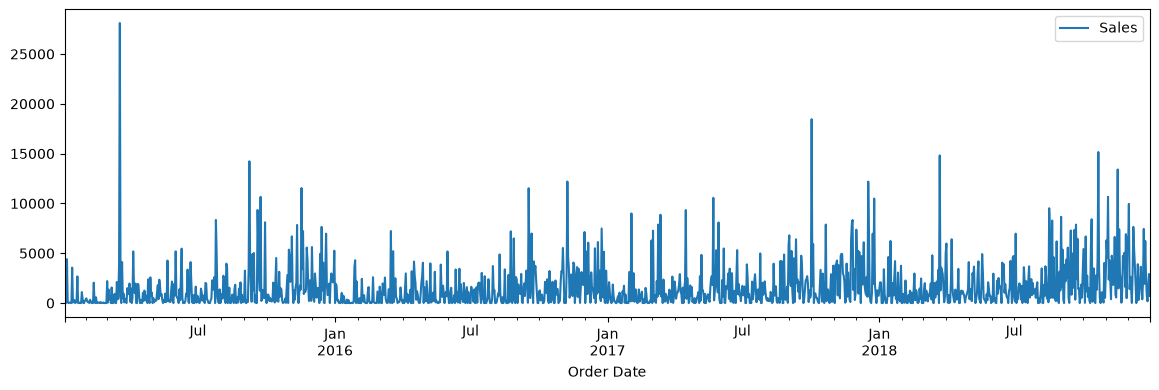

In [9]:
#RE-INDEXING TO FULL RANGE AND MISSING DAYS WITH NO SALES

daily_sales = daily_sales.set_index('Order Date').reindex(full_range, fill_value=0)
daily_sales.index.name = 'Order Date'
daily_sales = daily_sales.reset_index()

#PLOT

daily_sales.plot(x='Order Date', y='Sales', figsize=(14,4))

1458 calendar days but only 1230 had actual orders, meaning roughly 228 days (about 15%) had zero sales, which is completely normal for a retail business BECAUSE slow days happen. There's no strong long-term upward or downward trend, but the series is very spiky, lots of days near zero with sharp one-day peaks, one huge outlier around mid-2015

In [10]:
#RESAMPLE TO WEEKLY SALES
weekly_sales = daily_sales.set_index('Order Date')['Sales'].resample('W').sum().reset_index()

weekly_sales['year'] = weekly_sales['Order Date'].dt.year
weekly_sales['month'] = weekly_sales['Order Date'].dt.month
weekly_sales['quarter'] = weekly_sales['Order Date'].dt.quarter
weekly_sales['week_of_year'] = weekly_sales['Order Date'].dt.isocalendar().week.astype(int)

#ADDING LAG AND ROLLING FEATURES
weekly_sales['lag_1'] = weekly_sales['Sales'].shift(1)
weekly_sales['lag_4'] = weekly_sales['Sales'].shift(4)
weekly_sales['rolling_mean_4'] = weekly_sales['Sales'].shift(1).rolling(4).mean()

#ADDING A SEQUENTIAL TREND FEATURE (captures growth over time without memorising specific years)
weekly_sales['time_idx'] = range(len(weekly_sales))

#DROPPING THE FIRST FEW ROWS THAT HAVE NULL / NaN from the calculations
weekly_sales = weekly_sales.dropna().reset_index(drop=True)
print(weekly_sales.shape)
weekly_sales.head()

(205, 10)


,Order Date,Sales,year,month,quarter,week_of_year,lag_1,lag_4,rolling_mean_4,time_idx
0,2015-02-01,2527.914,2015,2,1,5,3092.544,304.508,3036.67325,4
1,2015-02-08,968.534,2015,2,1,6,2527.914,4619.108,3592.52475,5
2,2015-02-15,2771.054,2015,2,1,7,968.534,4130.533,2679.88125,6
3,2015-02-22,224.912,2015,2,1,8,2771.054,3092.544,2340.01150,7
4,2015-03-01,2289.643,2015,3,1,9,224.912,2527.914,1623.10350,8


In [11]:
#BUILD FORECASTING MODEL
#Let's define X and Y
from sklearn.linear_model import LinearRegression

feature_cols = ['month', 'time_idx', 'week_of_year', 'lag_1', 'lag_4', 'rolling_mean_4']
X = weekly_sales[feature_cols]
y = weekly_sales['Sales']

split_idx = int(len(weekly_sales) * 0.70)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f'Train: {X_train.shape[0]} weeks, Test: {X_test.shape[0]} weeks')

#FIT a baseline regression model   
model = LinearRegression()
model.fit(X_train, y_train)

#GENERATE the predictions for held-out text weeks
y_pred = model.predict(X_test)

Train: 143 weeks, Test: 62 weeks


In [12]:
pd.DataFrame({'actual': y_test.values, 'predicted': y_pred})

,actual,predicted
0,6625.8450,14564.779517
1,16321.3878,12569.036164
2,20640.3020,15819.900631
3,12641.7160,15491.750264
4,27367.7160,15972.770380
...,...,...
57,35998.9000,14621.876753
58,21537.2410,16425.765194
59,11542.8340,14736.332321
60,19457.0680,15716.876379


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE: 4936.05
RMSE: 6557.30
MAPE: 35.91%


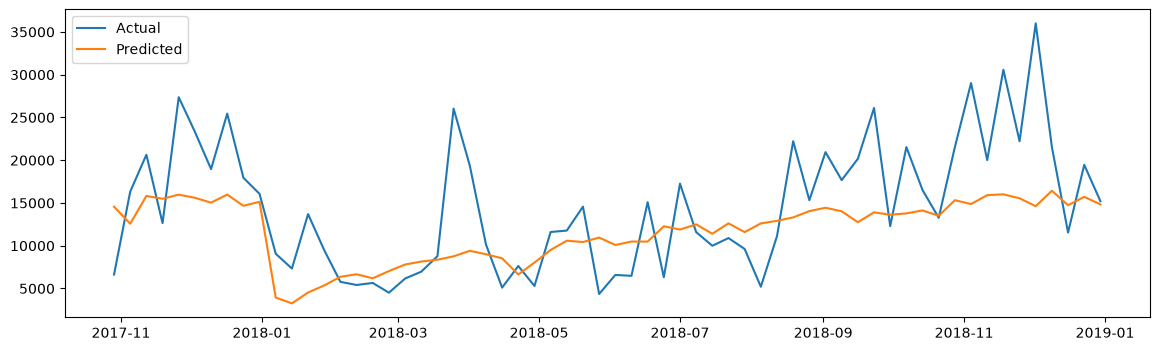

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], y_test.values, label='Actual')
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], y_pred, label='Predicted')
plt.legend()
plt.show()

In [15]:
print(dict(zip(feature_cols, model.coef_)))  

{'month': np.float64(100.27946128938922), 'time_idx': np.float64(20.981291539840484), 'week_of_year': np.float64(208.35385880247316), 'lag_1': np.float64(0.049185690283810146), 'lag_4': np.float64(-0.11205857935461161), 'rolling_mean_4': np.float64(-0.0643243925030621)}


In [16]:
#MODEL 2 - RANDOM FOREST (SAME TRAIN/TEST SPLIT AS LINEAR REGRESSION)
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [17]:
#RANDOM FOREST ERROR METRICS
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print(f'RF MAE: {rf_mae:.2f}')
print(f'RF RMSE: {rf_rmse:.2f}')
print(f'RF MAPE: {rf_mape:.2f}%')

RF MAE: 5160.83
RF RMSE: 6753.54
RF MAPE: 37.24%


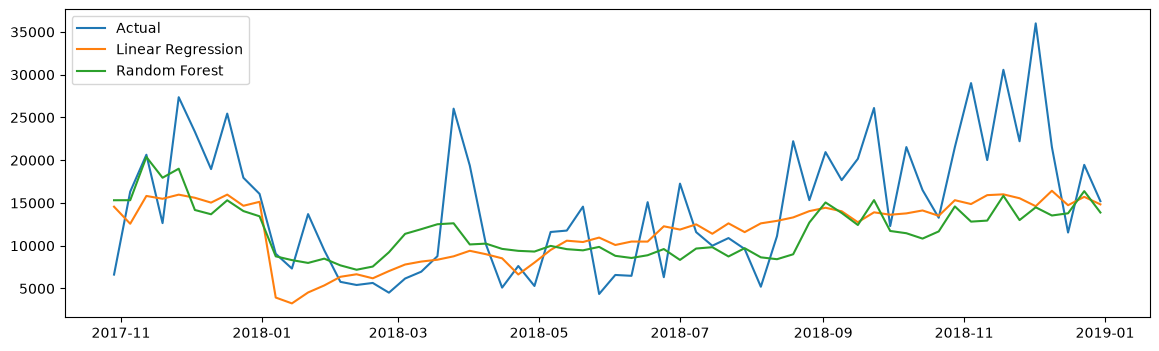

In [18]:
#ACTUAL VS LINEAR REGRESSION VS RANDOM FOREST
plt.figure(figsize=(14,4))
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], y_test.values, label='Actual')
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], y_pred, label='Linear Regression')
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], rf_pred, label='Random Forest')
plt.legend()
plt.show()

In [19]:
#RANDOM FOREST FEATURE IMPORTANCES
print(dict(zip(feature_cols, rf_model.feature_importances_)))

{'month': np.float64(0.08871482089226387), 'time_idx': np.float64(0.12304920781295166), 'week_of_year': np.float64(0.32415579360471936), 'lag_1': np.float64(0.09615759210637355), 'lag_4': np.float64(0.2754455430991042), 'rolling_mean_4': np.float64(0.09247704248458748)}


In [20]:
#MODEL 3 - ARIMA
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(weekly_sales['Sales'].iloc[:split_idx])
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

ADF Statistic: -6.2448
p-value: 0.0000


C:\Users\Admin\AppData\Local\Temp\ipykernel_19624\993565121.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(weekly_sales['Sales'].iloc[:split_idx])


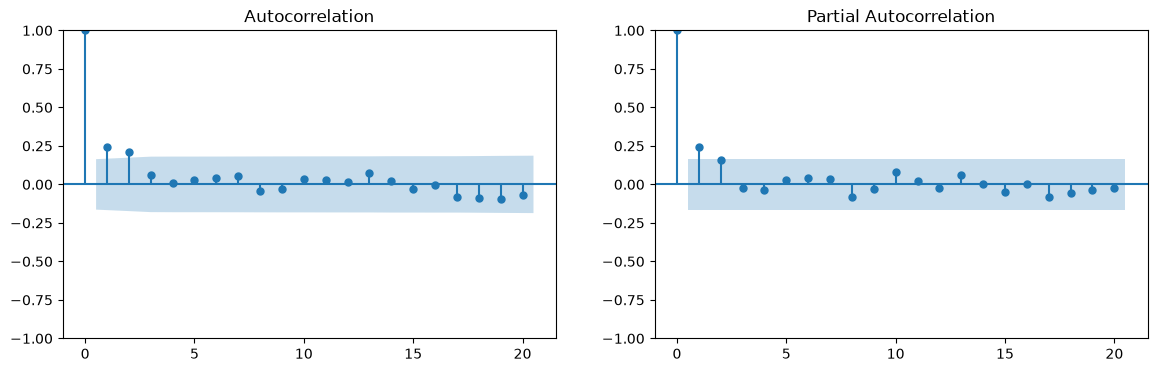

In [21]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(weekly_sales['Sales'].iloc[:split_idx], lags=20, ax=axes[0])
plot_pacf(weekly_sales['Sales'].iloc[:split_idx], lags=20, ax=axes[1])
plt.show()

In [22]:
from statsmodels.tsa.arima.model import ARIMA

train_series = weekly_sales['Sales'].iloc[:split_idx]
test_series = weekly_sales['Sales'].iloc[split_idx:]

In [23]:
orders_to_try = [(1,0,1), (2,0,1), (1,0,2), (2,0,2)]
aic_scores = {}

for order in orders_to_try:
    fitted = ARIMA(train_series, order=order).fit()
    aic_scores[order] = fitted.aic
    print(order, fitted.aic)

best_order = min(aic_scores, key=aic_scores.get)
print('Best order:', best_order)

arima_model = ARIMA(train_series, order=best_order).fit()

arima_pred = arima_model.forecast(steps=len(test_series))

(1, 0, 1) 2923.0662368465355
(2, 0, 1) 2923.9667012700065
(1, 0, 2) 2925.271018510065
(2, 0, 2) 2927.071741514639
Best order: (1, 0, 1)


In [24]:
arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))
arima_mape = np.mean(np.abs((test_series - arima_pred) / test_series)) * 100

print(f'ARIMA MAE: {arima_mae:.2f}')
print(f'ARIMA RMSE: {arima_rmse:.2f}')
print(f'ARIMA MAPE: {arima_mape:.2f}%')

ARIMA MAE: 7032.15
ARIMA RMSE: 9119.67
ARIMA MAPE: 45.72%


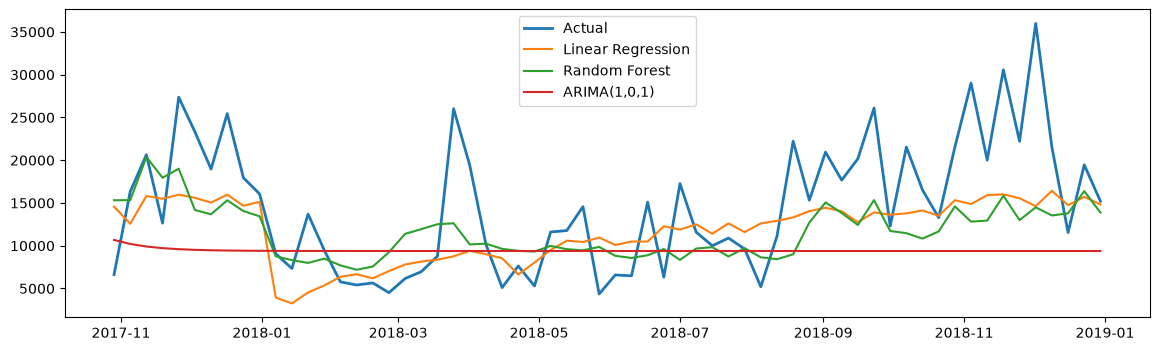

In [25]:
plt.figure(figsize=(14,4))
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], y_test.values, label='Actual', linewidth=2)
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], y_pred, label='Linear Regression')
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], rf_pred, label='Random Forest')
plt.plot(weekly_sales['Order Date'].iloc[split_idx:], arima_pred.values, label='ARIMA(1,0,1)')

plt.legend()
plt.show()

In [26]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print(f'RF MAE: {rf_mae:.2f}')
print(f'RF RMSE: {rf_rmse:.2f}')
print(f'RF MAPE: {rf_mape:.2f}%')

RF MAE: 5160.83
RF RMSE: 6753.54
RF MAPE: 37.24%


ARIMA is not going to work because it just predicted a flat average. Between Linear Regression and Random Forest, they're close enough (35.91% vs. 37.24%) that either is defensible, but Linear Regression is both the numerically best performer and the simplest, most explainable model. 

We will go with model 2, random forest.

In [27]:
# Retrain Random Forest on ALL available weeks (not just the 70% split)
final_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
final_model.fit(X, y)

# Build the future weeks to forecast
n_future_weeks = 8
last_date = weekly_sales['Order Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=n_future_weeks, freq='W')

# Recursive forecast: each predicted week feeds the lag features of the next
history = weekly_sales['Sales'].tolist()
future_preds = []

for i, date in enumerate(future_dates):
    row = {
        'month': date.month,
        'time_idx': len(weekly_sales) + i,
        'week_of_year': date.isocalendar()[1],
        'lag_1': history[-1],
        'lag_4': history[-4],
        'rolling_mean_4': np.mean(history[-4:]),
    }
    X_future = pd.DataFrame([row])[feature_cols]
    pred = final_model.predict(X_future)[0]
    future_preds.append(pred)
    history.append(pred)  # feed this prediction into the next week's lag features

future_df = pd.DataFrame({'Order Date': future_dates, 'Forecast': future_preds})
print(future_df)

  Order Date      Forecast
0 2019-01-06  14398.782279
1 2019-01-13  14384.916813
2 2019-01-20  14492.635579
3 2019-01-27  14469.510315
4 2019-02-03  14452.703337
5 2019-02-10  14382.179707
6 2019-02-17  14449.050190
7 2019-02-24  14385.620257


In [28]:
# Retrain Linear Regression on ALL available weeks (same as we did for the final Random Forest)
final_lr_model = LinearRegression()
final_lr_model.fit(X, y)

# Same recursive forecast loop, same future_dates, but using the linear model
lr_history = weekly_sales['Sales'].tolist()
lr_future_preds = []

for i, date in enumerate(future_dates):
    row = {
        'month': date.month,
        'time_idx': len(weekly_sales) + i,
        'week_of_year': date.isocalendar()[1],
        'lag_1': lr_history[-1],
        'lag_4': lr_history[-4],
        'rolling_mean_4': np.mean(lr_history[-4:]),
    }
    X_future = pd.DataFrame([row])[feature_cols]
    pred = final_lr_model.predict(X_future)[0]
    lr_future_preds.append(pred)
    lr_history.append(pred)

future_df['LR_Forecast'] = lr_future_preds
print(future_df)

  Order Date      Forecast   LR_Forecast
0 2019-01-06  14398.782279   7918.138826
1 2019-01-13  14384.916813   8459.042796
2 2019-01-20  14492.635579   7618.675260
3 2019-01-27  14469.510315   8001.333603
4 2019-02-03  14452.703337   9244.981544
5 2019-02-10  14382.179707   9507.022945
6 2019-02-17  14449.050190   9857.441424
7 2019-02-24  14385.620257  10088.178869


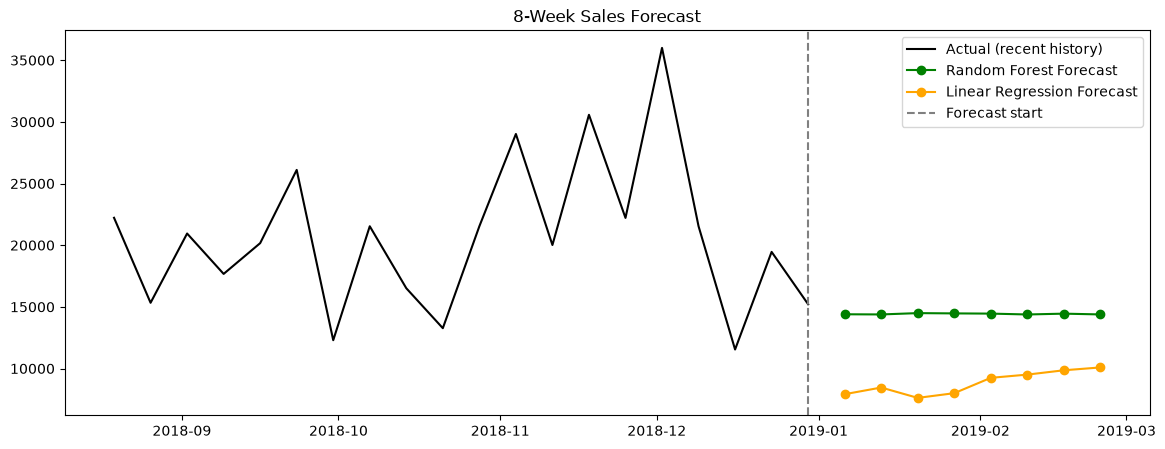

In [29]:
plt.figure(figsize=(14,5))

# last ~20 weeks of actual history for context
recent = weekly_sales.tail(20)
plt.plot(recent['Order Date'], recent['Sales'], label='Actual (recent history)', color='black')

plt.plot(future_df['Order Date'], future_df['Forecast'], label='Random Forest Forecast', marker='o', color='green')
plt.plot(future_df['Order Date'], future_df['LR_Forecast'], label='Linear Regression Forecast', marker='o', color='orange')

plt.axvline(x=weekly_sales['Order Date'].max(), color='gray', linestyle='--', label='Forecast start')
plt.legend()
plt.title('8-Week Sales Forecast')
plt.show()

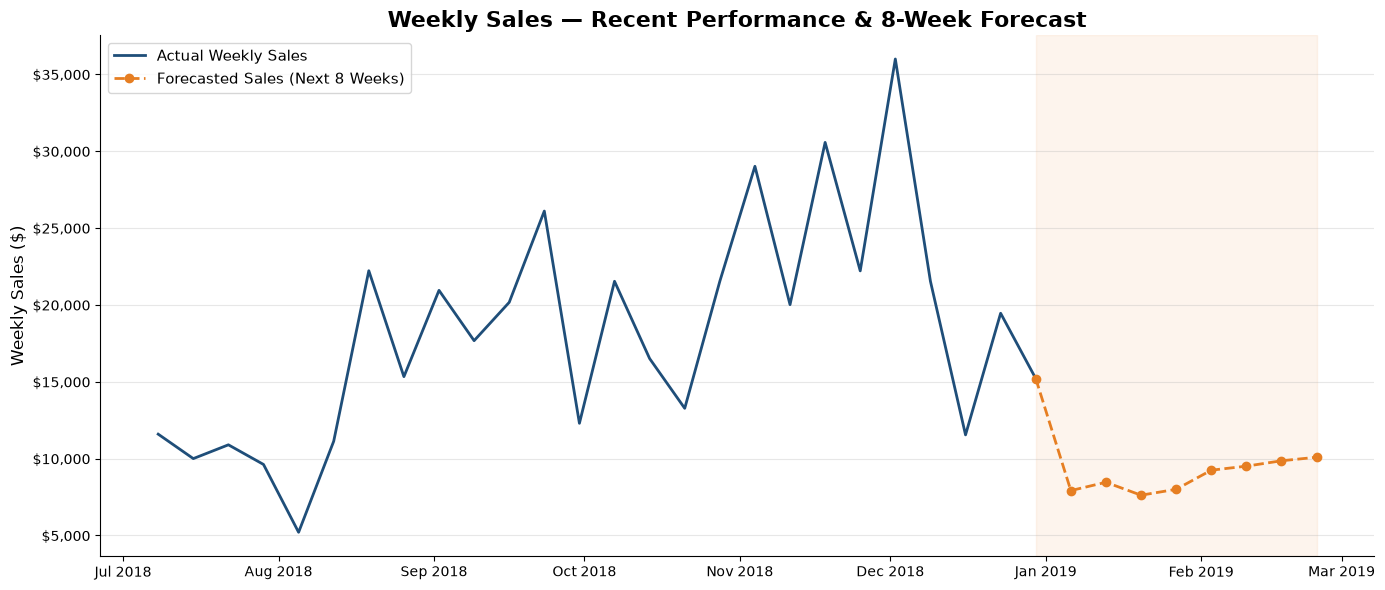

In [30]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

# Historical actuals (last ~26 weeks for readability — enough to show recent pattern without clutter)
recent = weekly_sales.tail(26)
ax.plot(recent['Order Date'], recent['Sales'], color='#1f4e79', linewidth=2, label='Actual Weekly Sales')

# Forecast (Linear Regression), connected to the last actual point so the line isn't broken
connect_date = pd.concat([weekly_sales[['Order Date']].tail(1).rename(columns={'Order Date':'Order Date'}), future_df[['Order Date']]])
connect_sales = pd.concat([weekly_sales['Sales'].tail(1), future_df['LR_Forecast']])
ax.plot(connect_date['Order Date'], connect_sales, color='#e67e22', linewidth=2, linestyle='--', marker='o', label='Forecasted Sales (Next 8 Weeks)')

# Shade the forecast region
ax.axvspan(weekly_sales['Order Date'].max(), future_df['Order Date'].max(), color='#e67e22', alpha=0.08)

# Formatting for a non-technical audience
ax.set_title('Weekly Sales — Recent Performance & 8-Week Forecast', fontsize=16, fontweight='bold')
ax.set_ylabel('Weekly Sales ($)', fontsize=12)
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=11, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sales_forecast_chart.png', dpi=150, bbox_inches='tight')
plt.show()